In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, f1_score
from preprocessing import get_features_and_target
from visualizer import plot_visualizer, plot_visualizer_classification
import plotly.graph_objects as go
from sklearn.model_selection import StratifiedKFold
from preprocessing import get_features_and_target_classification
from tabpfn import TabPFNClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

In [2]:
import huggingface_hub
huggingface_hub.login()

# Getting Dataframe

In [3]:
# Load the training and development datasets
train_df = pd.read_csv("data/train_data.csv")
dev_df = pd.read_csv("data/development_data.csv")
sc = StandardScaler()

target_column = "Category" 

x_train, y_train = get_features_and_target(train_df, target_column)
x_dev, y_dev = get_features_and_target(dev_df, target_column)

x_train_scale = sc.fit_transform(X=x_train)
x_dev_scale = sc.transform(x_dev)


# Defining Model

In [4]:
#model = 'XGBoost'
#model = 'TabPFNClassifier'
model = 'RandomForest'

# Add Physical Columns Interfacial_Failure and Pullout_Failure

In [5]:
def compute_interfacial_failure(df):
     t = df[['Thickness A (mm)', 'Thickness B (mm)']].min(axis=1) 
     f_pull = 1 * (np.pi/4) * (4 * np.sqrt(t))**2 * (0.7 * 365) 
     return np.round(f_pull, 1) 

def compute_pullout_failure(df):
     t = df[['Thickness A (mm)', 'Thickness B (mm)']].min(axis=1) 
     f_pull = np.pi * ((4 * np.sqrt(t)) + 2*t)*t*365 
     return np.round(f_pull, 1) 

x_train['Interfacial_Failure'] = compute_interfacial_failure(x_train) 
x_train['Pullout_Failure'] = compute_pullout_failure(x_train) 
x_dev['Interfacial_Failure'] = compute_interfacial_failure(x_dev)
x_dev['Pullout_Failure'] = compute_pullout_failure(x_dev)

In [6]:
x_train.head(50)

,Pressure (PSI),Welding Time (ms),Angle (Deg),Force (N),Current (A),Thickness A (mm),Thickness B (mm),Interfacial_Failure,Pullout_Failure
0,35,200,0,6.82,1081.47,0.922,0.920,2953.9,5988.6
1,35,1500,0,52.25,2014.73,0.920,0.925,2953.9,5988.6
2,95,200,0,16.57,1321.93,0.912,0.924,2928.2,5902.3
3,95,200,0,41.42,1615.83,0.948,0.939,3014.9,6195.6
4,35,1500,0,63.82,1137.29,0.930,0.937,2986.0,6097.2
5,35,200,0,16.47,1083.06,0.932,0.928,2979.5,6075.4
6,95,1500,0,129.13,1112.82,0.937,0.927,2976.3,6064.5
7,95,200,0,16.55,1357.87,0.929,0.915,2937.8,5934.6
8,35,1500,0,46.58,1123.59,0.931,0.938,2989.2,6108.1
9,95,200,15,6.67,1840.75,1.057,0.936,3005.2,6162.7


# Fit Model

In [7]:


if model == 'TabPFNClassifier':
    # Target value

    classifier = TabPFNClassifier() 

    classifier.fit(x_train_scale,y_train)

    predictions = classifier.predict(x_dev_scale)

elif model == 'RandomForest':
    # Target value

    # Set the parameters for the Random Forest model
    params = {
            'n_estimators': 20,
            'max_depth': 11,
            'min_samples_split': 5,
            'min_samples_leaf': 5,
            'random_state': 42,
    }

    predictions = RandomForestClassifier(**params).fit(x_train_scale, y_train).predict(x_dev_scale)

# Check Validation Data

In [8]:
#test_x = x_dev.iloc[:50].copy()
#test_x.columns

In [9]:
#feature_names = x_train.columns.tolist()
# Fix: tell SHAP what the model's feature names are 
#classifier.feature_names_in_ = np.array(feature_names)

# Calculate SHAP values
#shap_values = interpretability.shap.get_shap_values(
#    estimator=classifier,
#    test_x=test_x,
#    attribute_names=feature_names,
#    algorithm="permutation",
#)

# Create visualization
#fig = interpretability.shap.plot_shap(shap_values)

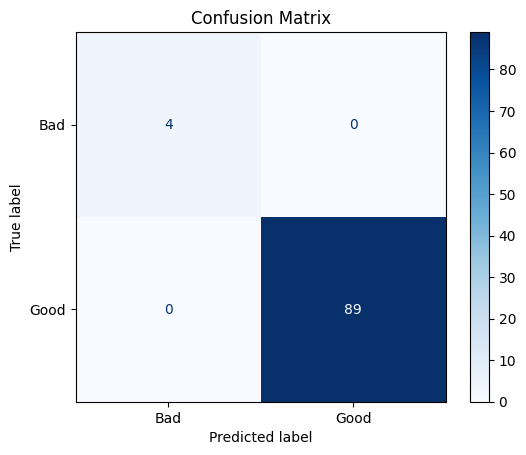

F1 Score: 0.6557971014492754


In [10]:
# Plot classification
plot_visualizer_classification(
    y_true=y_dev,
    y_pred=predictions,
    class_labels=["Bad", "Good"],
    title=f"Confusion Matrix"
)


# Cross Validation

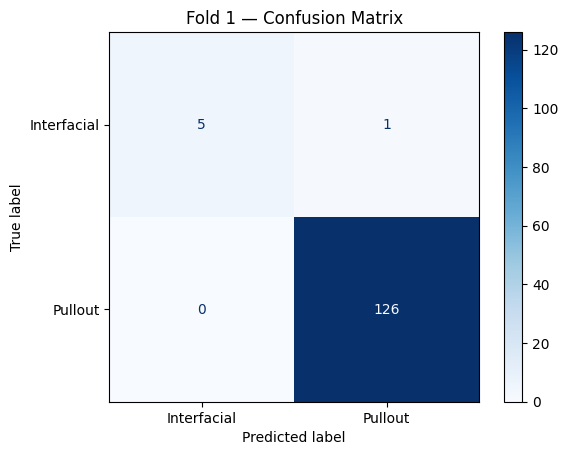

F1 Score: 0.9525691699604744


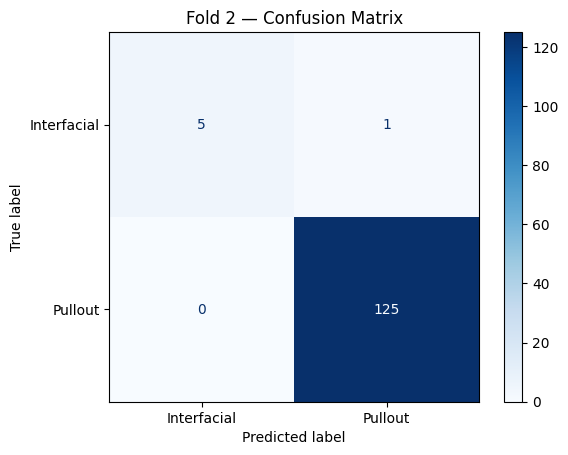

F1 Score: 0.9525534226729446


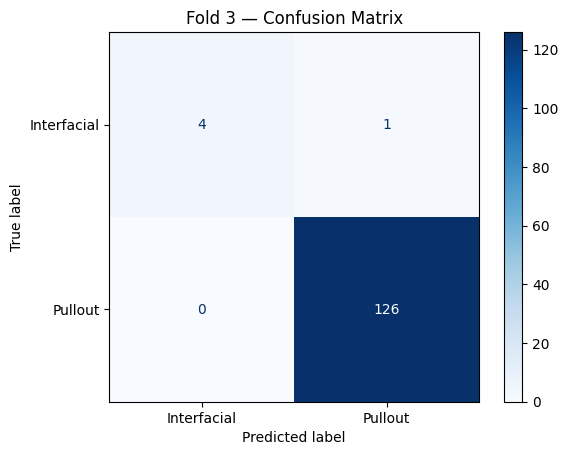

F1 Score: 0.9424681598594642
F1 Score: 0.9491969174976278


In [11]:
from random import randint


cross_df = pd.read_csv("data/train_dev_data.csv")

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

mapping = {
    "Explode": "Pullout",
    "Good": "Pullout",
    "Bad": "Interfacial"
}

def apply_mapping(arr):
    return np.array([mapping[x] for x in arr])


mean_list = []

for fold, (train_index, val_index) in enumerate(skf.split(cross_df["Sample ID"], cross_df["Category"])):
    x_tr, y_tr = get_features_and_target(cross_df.iloc[train_index], target_column) 
    x_val, y_val = get_features_and_target(cross_df.iloc[val_index], target_column)

    y_tr = apply_mapping(y_tr)
    y_val = apply_mapping(y_val)

    x_tr_scale = sc.fit_transform(X=x_tr)
    x_val_scale = sc.transform(x_val)

    if model == 'XGBoost':
        dtrain = xgb.DMatrix(x_tr_scale, label=y_tr)
        dval = xgb.DMatrix(x_val_scale, label=y_val)

        params = {
            'objective': 'reg:squarederror',
            'max_depth': 1,
            'eta': 0.57,
            'eval_metric': 'rmse'
        }

        num_boost_round = 20
        bst = xgb.train(params, dtrain, num_boost_round)

        preds = bst.predict(dval)

    elif model == 'RandomForest':

        params = {
            'n_estimators': 100,
            'max_depth': 2, 
            'min_samples_split': 2,
            'min_samples_leaf': 1,
            'max_features': "sqrt",
        }

        classifier = RandomForestClassifier(**params)
        classifier.fit(x_tr_scale, y_tr)
        
        preds = classifier.predict(x_val_scale)
        
    elif model == 'TabPFN':
        classifier = TabPFNClassifier()
        classifier.fit(x_tr, y_tr)

        preds = classifier.predict(x_val)


    f1 = f1_score(y_val, preds, average="macro")

    
    mean_list.append(f1)

    # Plot classification results for this fold
    plot_visualizer_classification(
        y_true=y_val,
        y_pred=preds,
        class_labels=["Interfacial", "Pullout"],
        title=f"Fold {fold+1} — Confusion Matrix"
    )

f1_mean = np.mean(mean_list) 
# Final Evaluation over all Folds
print("F1 Score:", f1_mean)

# Parametertuning

In [34]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

model_name = "xgb"  # or rf

def create_classifier(model_name, params):
    if model_name == "rf":
        return RandomForestClassifier(**params, random_state=42)
    elif model_name == "xgb":
        return XGBClassifier(
            **params,
            random_state=42,
            tree_method="hist",
            eval_metric="rmse"
        )
    else:
        raise ValueError(f"Unknown model: {model_name}")

In [35]:
from scipy.stats import randint, uniform

param_spaces = {
    "rf": {
        "n_estimators": randint(10, 100),    #Für ersten Durchlauf: randint(100, 500)
        "max_depth": randint(2, 10),
        "min_samples_split": randint(2, 10),
        "min_samples_leaf": randint(1, 5),
        "max_features": ["sqrt", "log2", None],
    },
    "xgb": {
        'max_depth' : randint(2, 10),
        'learning_rate': randint(1, 11), 
        'n_estimators' : randint(50, 200),  #Erster durchlauf: randint(1, 11)

    }
}

In [36]:
import numpy as np

def sample_params(space):
    params = {}

    for k, v in space.items():

        # Case 1: categorical list
        if isinstance(v, list):
            val = np.random.choice(v)

        # Case 2: scipy.stats distribution
        else:
            val = v.rvs()

            if k == "learning_rate":
                val = round(val / 10.0, 1)

            if hasattr(val, "item"):
                val = val.item()

        params[k] = val

    return params


In [49]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
import numpy as np
from sklearn.preprocessing import LabelEncoder
from torch import le

def randomized_cv_search_classifier(model_name, cross_df, target_column, n_iter):
    space = param_spaces[model_name]

    best_f1 = -1
    best_params = None
    best_model = None

    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

    mapping = {
    "Explode": "Pullout",
    "Good": "Pullout",
    "Bad": "Interfacial"
    }

    def apply_mapping(arr):
        return np.array([mapping[x] for x in arr])

    for i in range(n_iter):
        params = sample_params(space)
        print(f"\nTesting params: {params}")

        f1_list = []

        for fold, (train_index, val_index) in enumerate(
                skf.split(cross_df["Sample ID"], cross_df[target_column])):

            train_df = cross_df.iloc[train_index].copy()
            val_df   = cross_df.iloc[val_index].copy()

            X_tr, y_tr = get_features_and_target(train_df, target_column)
            X_val, y_val = get_features_and_target(val_df, target_column)

            y_tr = apply_mapping(y_tr)
            y_val = apply_mapping(y_val)

            # XGBoost requires integer labels
            from sklearn.preprocessing import LabelEncoder
            le = LabelEncoder()

            y_tr = le.fit_transform(y_tr)
            y_val = le.transform(y_val)


            X_tr_scale = sc.fit_transform(X_tr)
            X_val_scale = sc.transform(X_val)

            model = create_classifier(model_name, params)
            model.fit(X_tr_scale, y_tr)

            preds = model.predict(X_val_scale)

            f1 = f1_score(y_val, preds, average="macro")
            f1_list.append(f1)

        f1_mean = np.mean(f1_list)
        print(f"F1={f1_mean:.3f}")

        if f1_mean >= best_f1:
            best_f1 = f1_mean
            best_params = params
            best_model = model

    return best_model, best_params, best_f1


In [50]:
best_model, best_params, best_f1= randomized_cv_search_classifier(
    model_name="xgb",         # rf or xgb
    cross_df=cross_df,
    target_column="Category",
    n_iter=10000
)


Testing params: {'max_depth': 8, 'learning_rate': 0.7, 'n_estimators': 55}
F1=0.949

Testing params: {'max_depth': 3, 'learning_rate': 0.6, 'n_estimators': 94}
F1=0.949

Testing params: {'max_depth': 7, 'learning_rate': 0.1, 'n_estimators': 61}
F1=0.949

Testing params: {'max_depth': 7, 'learning_rate': 0.7, 'n_estimators': 190}
F1=0.949

Testing params: {'max_depth': 3, 'learning_rate': 0.3, 'n_estimators': 115}
F1=0.949

Testing params: {'max_depth': 9, 'learning_rate': 0.8, 'n_estimators': 108}
F1=0.949

Testing params: {'max_depth': 6, 'learning_rate': 0.4, 'n_estimators': 96}
F1=0.949

Testing params: {'max_depth': 2, 'learning_rate': 0.4, 'n_estimators': 126}
F1=0.949

Testing params: {'max_depth': 6, 'learning_rate': 0.2, 'n_estimators': 180}
F1=0.949

Testing params: {'max_depth': 5, 'learning_rate': 0.4, 'n_estimators': 153}
F1=0.949

Testing params: {'max_depth': 6, 'learning_rate': 0.2, 'n_estimators': 64}
F1=0.949

Testing params: {'max_depth': 8, 'learning_rate': 0.9, 'n_

In [52]:
print("\n==============================")
print(" BEST MODEL FOUND ")
print("==============================")
print(f"Best F1:   {best_f1:.2f}")
print(f"Best Params: {best_params}")

#==============================
# BEST MODEL FOUND XGBoost
#==============================

#Best F1:   0.95
#Best Params: {'max_depth': 9, 'learning_rate': 0.3, 'n_estimators': 177}
#Picked Model: {'n_estimators': 200, 'max_depth': 5, 'lr': 0.3}
#==============================
# BEST MODEL FOUND Random Forest
#==============================
#Best F1: 0,95
#Best Params: {'n_estimators': 100, 'max_depth': 11, 'min_samples_split': 5, 'min_samples_leaf': 5, 'max_features': 'sqrt'}
#Best F1:   0.95
#Best Params: {'n_estimators': 27, 'max_depth': 7, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2'}
#Picked Model: {'n_estimators': 100, 'max_depth': 2, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt'}




 BEST MODEL FOUND 
Best F1:   0.95
Best Params: {'max_depth': 9, 'learning_rate': 0.3, 'n_estimators': 177}
